In [ ]:
import os, glob, json, ast, random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import f1_score
from transformers import BertModel, BertTokenizer
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch.optim import AdamW

PROJECT_ROOT = os.getcwd()
RAW = os.path.join(PROJECT_ROOT, "data/raw")
PROC = os.path.join(PROJECT_ROOT, "data/processed")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
os.makedirs(os.path.join(RESULTS_DIR, "plots"), exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

d:\Program Files\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
mc = pd.read_csv(os.path.join(RAW, "musiccaps/musiccaps-public.csv"))
mc_graph_manifest = pd.read_csv(os.path.join(PROC, "musiccaps_graph_manifest.csv"))

successful_ids = set(mc_graph_manifest[mc_graph_manifest["success"] == True]["ytid"])
mc_final = mc[mc["ytid"].isin(successful_ids)].reset_index(drop=True)
print("Matched clips:", len(mc_final))

print(mc_final.iloc[0]["aspect_list"])
print(type(mc_final.iloc[0]["aspect_list"]))

Matched clips: 1159
['low quality', 'sustained strings melody', 'soft female vocal', 'mellow piano melody', 'sad', 'soulful', 'ballad']
<class 'str'>


Step 2 — Parse aspect_list, build top-K tag vocabulary

In [ ]:
mc_final["aspect_parsed"] = mc_final["aspect_list"].apply(ast.literal_eval)


all_aspects = [a for aspects in mc_final["aspect_parsed"] for a in aspects]
print("Total aspect mentions:", len(all_aspects))
print("Unique aspect phrases:", len(set(all_aspects)))

from collections import Counter
aspect_counts = Counter(all_aspects)
print(aspect_counts.most_common(20))

Total aspect mentions: 12380
Unique aspect phrases: 4219
[('low quality', 252), ('instrumental', 184), ('emotional', 145), ('passionate', 145), ('energetic', 131), ('noisy', 129), ('medium tempo', 120), ('amateur recording', 109), ('slow tempo', 108), ('live performance', 90), ('acoustic drums', 86), ('fast tempo', 85), ('acoustic guitar', 72), ('mono', 70), ('bass guitar', 63), ('electric guitar', 61), ('piano', 60), ('e-bass', 53), ('groovy', 53), ('pop', 51)]


In [4]:
top50_aspects = aspect_counts.most_common(50)
for phrase, count in top50_aspects:
    print(f"{phrase}: {count}")

low quality: 252
instrumental: 184
emotional: 145
passionate: 145
energetic: 131
noisy: 129
medium tempo: 120
amateur recording: 109
slow tempo: 108
live performance: 90
acoustic drums: 86
fast tempo: 85
acoustic guitar: 72
mono: 70
bass guitar: 63
electric guitar: 61
piano: 60
e-bass: 53
groovy: 53
pop: 51
uptempo: 51
poor audio quality: 50
male voice: 50
instrumental music: 50
shimmering hi hats: 50
punchy snare: 49
rock: 48
groovy bass: 48
youthful: 48
punchy kick: 47
spirited: 46
male vocal: 45
moderate tempo: 44
romantic: 44
upbeat: 43
happy: 43
mellow: 41
exciting: 41
bass: 40
percussion: 40
electronic drums: 40
male singer: 39
enthusiastic: 39
sentimental: 38
digital drums: 36
groovy bass line: 35
keyboard: 35
no voices: 34
lively: 34
keyboard harmony: 32


In [ ]:
top30_aspects = [phrase for phrase, count in aspect_counts.most_common(30)]
print(top30_aspects)


for tag in top30_aspects:
    mc_final[tag] = mc_final["aspect_parsed"].apply(lambda aspects: 1 if tag in aspects else 0)

print(mc_final[top30_aspects].sum().sort_values(ascending=False))
print(mc_final.shape)

['low quality', 'instrumental', 'emotional', 'passionate', 'energetic', 'noisy', 'medium tempo', 'amateur recording', 'slow tempo', 'live performance', 'acoustic drums', 'fast tempo', 'acoustic guitar', 'mono', 'bass guitar', 'electric guitar', 'piano', 'e-bass', 'groovy', 'pop', 'uptempo', 'poor audio quality', 'male voice', 'instrumental music', 'shimmering hi hats', 'punchy snare', 'rock', 'groovy bass', 'youthful', 'punchy kick']
low quality           252
instrumental          184
emotional             144
passionate            144
energetic             131
noisy                 128
medium tempo          120
amateur recording     108
slow tempo            107
live performance       88
acoustic drums         86
fast tempo             84
acoustic guitar        70
mono                   70
bass guitar            63
electric guitar        61
piano                  60
e-bass                 53
groovy                 53
uptempo                51
pop                    50
male voice      

Step 3 — Train/val/test split

In [6]:
random.seed(42)
indices = list(range(len(mc_final)))
random.shuffle(indices)

n = len(indices)
train_end, val_end = int(0.8*n), int(0.9*n)

mc_train = mc_final.iloc[indices[:train_end]].reset_index(drop=True)
mc_val = mc_final.iloc[indices[train_end:val_end]].reset_index(drop=True)
mc_test = mc_final.iloc[indices[val_end:]].reset_index(drop=True)

print("Train:", len(mc_train), "| Val:", len(mc_val), "| Test:", len(mc_test))

Train: 927 | Val: 116 | Test: 116


Step 4 — combining graph batching with text batching

In [ ]:
from torch_geometric.data import Batch
from torch.utils.data import Dataset, DataLoader

MC_GRAPH_DIR = os.path.join(PROC, "musiccaps_graphs")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

class FusionDataset(Dataset):
    def __init__(self, df, tag_cols, graph_dir, tokenizer, max_length=128):
        self.df = df.reset_index(drop=True)
        self.tag_cols = tag_cols
        self.graph_dir = graph_dir
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        graph = torch.load(os.path.join(self.graph_dir, f"{row['ytid']}.pt"), weights_only=False)
        tokens = self.tokenizer(row["caption"], padding="max_length", truncation=True,
                                 max_length=self.max_length, return_tensors="pt")
        label = torch.tensor(row[self.tag_cols].values.astype(np.float32))
        return graph, tokens["input_ids"].squeeze(0), tokens["attention_mask"].squeeze(0), label

def fusion_collate(batch):
    graphs, input_ids, attn_masks, labels = zip(*batch)
    graph_batch = Batch.from_data_list(list(graphs))  
    return graph_batch, torch.stack(input_ids), torch.stack(attn_masks), torch.stack(labels)

train_dataset_fusion = FusionDataset(mc_train, top30_aspects, MC_GRAPH_DIR, tokenizer)
val_dataset_fusion = FusionDataset(mc_val, top30_aspects, MC_GRAPH_DIR, tokenizer)
test_dataset_fusion = FusionDataset(mc_test, top30_aspects, MC_GRAPH_DIR, tokenizer)

BATCH_SIZE_FUSION = 8 

train_loader_fusion = DataLoader(train_dataset_fusion, batch_size=BATCH_SIZE_FUSION, shuffle=True, collate_fn=fusion_collate)
val_loader_fusion = DataLoader(val_dataset_fusion, batch_size=BATCH_SIZE_FUSION, collate_fn=fusion_collate)
test_loader_fusion = DataLoader(test_dataset_fusion, batch_size=BATCH_SIZE_FUSION, collate_fn=fusion_collate)


graph_batch, input_ids, attn_mask, labels = next(iter(train_loader_fusion))
print("Graph batch:", graph_batch)
print("Input IDs shape:", input_ids.shape)
print("Labels shape:", labels.shape)

Graph batch: DataBatch(x=[40, 12], edge_index=[2, 116], batch=[40], ptr=[9])
Input IDs shape: torch.Size([8, 128])
Labels shape: torch.Size([8, 30])


Step 5 — GNN–BERT fusion model

In [ ]:
class GNNBERTFusion(nn.Module):
    def __init__(self, num_tags=30, gnn_hidden=64, bert_hidden=768):
        super().__init__()
        # GNN branch 
        self.conv1 = SAGEConv(12, gnn_hidden)
        self.conv2 = SAGEConv(gnn_hidden, gnn_hidden)

        # BERT branch 
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.query_proj = nn.Linear(gnn_hidden, bert_hidden)
        self.key_proj = nn.Linear(bert_hidden, bert_hidden)
        self.value_proj = nn.Linear(bert_hidden, bert_hidden)

        # Final classifier on concatenated [g, attended_text]
        self.classifier = nn.Linear(gnn_hidden + bert_hidden, num_tags)

    def forward(self, graph_batch, input_ids, attention_mask):
        # --- GNN branch ---
        x = F.relu(self.conv1(graph_batch.x, graph_batch.edge_index))
        x = F.relu(self.conv2(x, graph_batch.edge_index))
        g = global_mean_pool(x, graph_batch.batch) 

        # --- BERT branch ---
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        H_text = bert_out.last_hidden_state 

        # --- Cross-attention: 
        Q = self.query_proj(g).unsqueeze(1)          
        K = self.key_proj(H_text)                    
        V = self.value_proj(H_text)                   

        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / (K.size(-1) ** 0.5)  
        attn_weights = F.softmax(attn_scores, dim=-1)
        attended_text = torch.matmul(attn_weights, V).squeeze(1)  

        # --- Fusion + classification ---
        z = torch.cat([g, attended_text], dim=-1)
        return self.classifier(z)

fusion_model = GNNBERTFusion(num_tags=30).to(device)
print("Model created. Parameter count:", sum(p.numel() for p in fusion_model.parameters()))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3582.00it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model created. Parameter count: 110748190


In [ ]:
# Quick forward-pass test 
fusion_model.eval()
with torch.no_grad():
    graph_batch, input_ids, attn_mask, labels = next(iter(train_loader_fusion))
    graph_batch = graph_batch.to(device)
    input_ids, attn_mask = input_ids.to(device), attn_mask.to(device)
    logits = fusion_model(graph_batch, input_ids, attn_mask)
    print("Output shape:", logits.shape)  

Output shape: torch.Size([8, 30])


Step 6 — Training loop

In [ ]:
criterion_fusion = nn.BCEWithLogitsLoss()
optimizer_fusion = AdamW(fusion_model.parameters(), lr=2e-5)

def evaluate_fusion(loader):
    fusion_model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for graph_batch, input_ids, attn_mask, labels in loader:
            graph_batch = graph_batch.to(device)
            input_ids, attn_mask, labels = input_ids.to(device), attn_mask.to(device), labels.to(device)
            logits = fusion_model(graph_batch, input_ids, attn_mask)
            loss = criterion_fusion(logits, labels)
            total_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    return total_loss / len(loader), macro_f1, micro_f1

fusion_history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_micro_f1": []}
EPOCHS_FUSION = 5 

for epoch in range(EPOCHS_FUSION):
    fusion_model.train()
    train_loss = 0
    for graph_batch, input_ids, attn_mask, labels in tqdm(train_loader_fusion, desc=f"Epoch {epoch+1}"):
        graph_batch = graph_batch.to(device)
        input_ids, attn_mask, labels = input_ids.to(device), attn_mask.to(device), labels.to(device)

        optimizer_fusion.zero_grad()
        logits = fusion_model(graph_batch, input_ids, attn_mask)
        loss = criterion_fusion(logits, labels)
        loss.backward()
        optimizer_fusion.step()
        train_loss += loss.item()

    val_loss, val_macro_f1, val_micro_f1 = evaluate_fusion(val_loader_fusion)
    fusion_history["train_loss"].append(train_loss/len(train_loader_fusion))
    fusion_history["val_loss"].append(val_loss)
    fusion_history["val_macro_f1"].append(val_macro_f1)
    fusion_history["val_micro_f1"].append(val_micro_f1)
    print(f"Epoch {epoch+1}: train_loss={train_loss/len(train_loader_fusion):.4f} | "
          f"val_loss={val_loss:.4f} | val_macro_f1={val_macro_f1:.4f} | val_micro_f1={val_micro_f1:.4f}")

Epoch 1: 100%|██████████| 116/116 [00:45<00:00,  2.53it/s]


Epoch 1: train_loss=0.3083 | val_loss=0.2340 | val_macro_f1=0.0369 | val_micro_f1=0.1479


Epoch 2: 100%|██████████| 116/116 [00:30<00:00,  3.83it/s]


Epoch 2: train_loss=0.2060 | val_loss=0.2048 | val_macro_f1=0.1105 | val_micro_f1=0.2794


Epoch 3: 100%|██████████| 116/116 [00:30<00:00,  3.81it/s]


Epoch 3: train_loss=0.1728 | val_loss=0.1765 | val_macro_f1=0.1978 | val_micro_f1=0.3512


Epoch 4: 100%|██████████| 116/116 [00:30<00:00,  3.77it/s]


Epoch 4: train_loss=0.1503 | val_loss=0.1567 | val_macro_f1=0.3270 | val_micro_f1=0.5422


Epoch 5: 100%|██████████| 116/116 [00:30<00:00,  3.76it/s]


Epoch 5: train_loss=0.1330 | val_loss=0.1512 | val_macro_f1=0.3843 | val_micro_f1=0.5742


In [11]:
EXTRA_EPOCHS_FUSION = 5
for epoch in range(EXTRA_EPOCHS_FUSION):
    fusion_model.train()
    train_loss = 0
    for graph_batch, input_ids, attn_mask, labels in tqdm(train_loader_fusion, desc=f"Epoch {len(fusion_history['train_loss'])+1}"):
        graph_batch = graph_batch.to(device)
        input_ids, attn_mask, labels = input_ids.to(device), attn_mask.to(device), labels.to(device)
        optimizer_fusion.zero_grad()
        logits = fusion_model(graph_batch, input_ids, attn_mask)
        loss = criterion_fusion(logits, labels)
        loss.backward()
        optimizer_fusion.step()
        train_loss += loss.item()

    val_loss, val_macro_f1, val_micro_f1 = evaluate_fusion(val_loader_fusion)
    fusion_history["train_loss"].append(train_loss/len(train_loader_fusion))
    fusion_history["val_loss"].append(val_loss)
    fusion_history["val_macro_f1"].append(val_macro_f1)
    fusion_history["val_micro_f1"].append(val_micro_f1)
    print(f"Epoch {len(fusion_history['train_loss'])}: train_loss={train_loss/len(train_loader_fusion):.4f} | "
          f"val_loss={val_loss:.4f} | val_macro_f1={val_macro_f1:.4f} | val_micro_f1={val_micro_f1:.4f}")

Epoch 6: 100%|██████████| 116/116 [00:31<00:00,  3.63it/s]


Epoch 6: train_loss=0.1204 | val_loss=0.1421 | val_macro_f1=0.4470 | val_micro_f1=0.6037


Epoch 7: 100%|██████████| 116/116 [00:31<00:00,  3.72it/s]


Epoch 7: train_loss=0.1083 | val_loss=0.1382 | val_macro_f1=0.4856 | val_micro_f1=0.6202


Epoch 8: 100%|██████████| 116/116 [00:31<00:00,  3.71it/s]


Epoch 8: train_loss=0.0969 | val_loss=0.1309 | val_macro_f1=0.5154 | val_micro_f1=0.6420


Epoch 9: 100%|██████████| 116/116 [00:31<00:00,  3.72it/s]


Epoch 9: train_loss=0.0867 | val_loss=0.1268 | val_macro_f1=0.5531 | val_micro_f1=0.6711


Epoch 10: 100%|██████████| 116/116 [00:31<00:00,  3.73it/s]


Epoch 10: train_loss=0.0758 | val_loss=0.1263 | val_macro_f1=0.5671 | val_micro_f1=0.6740


In [12]:
EXTRA_EPOCHS_FUSION = 3
for epoch in range(EXTRA_EPOCHS_FUSION):
    fusion_model.train()
    train_loss = 0
    for graph_batch, input_ids, attn_mask, labels in tqdm(train_loader_fusion, desc=f"Epoch {len(fusion_history['train_loss'])+1}"):
        graph_batch = graph_batch.to(device)
        input_ids, attn_mask, labels = input_ids.to(device), attn_mask.to(device), labels.to(device)
        optimizer_fusion.zero_grad()
        logits = fusion_model(graph_batch, input_ids, attn_mask)
        loss = criterion_fusion(logits, labels)
        loss.backward()
        optimizer_fusion.step()
        train_loss += loss.item()

    val_loss, val_macro_f1, val_micro_f1 = evaluate_fusion(val_loader_fusion)
    fusion_history["train_loss"].append(train_loss/len(train_loader_fusion))
    fusion_history["val_loss"].append(val_loss)
    fusion_history["val_macro_f1"].append(val_macro_f1)
    fusion_history["val_micro_f1"].append(val_micro_f1)
    print(f"Epoch {len(fusion_history['train_loss'])}: train_loss={train_loss/len(train_loader_fusion):.4f} | "
          f"val_loss={val_loss:.4f} | val_macro_f1={val_macro_f1:.4f} | val_micro_f1={val_micro_f1:.4f}")

Epoch 11: 100%|██████████| 116/116 [00:31<00:00,  3.64it/s]


Epoch 11: train_loss=0.0671 | val_loss=0.1194 | val_macro_f1=0.6139 | val_micro_f1=0.7034


Epoch 12: 100%|██████████| 116/116 [00:30<00:00,  3.76it/s]


Epoch 12: train_loss=0.0585 | val_loss=0.1119 | val_macro_f1=0.6293 | val_micro_f1=0.7134


Epoch 13: 100%|██████████| 116/116 [00:30<00:00,  3.79it/s]


Epoch 13: train_loss=0.0502 | val_loss=0.1196 | val_macro_f1=0.6253 | val_micro_f1=0.7115


FUSION TEST: loss=0.1086 | macro_f1=0.5329 | micro_f1=0.7007


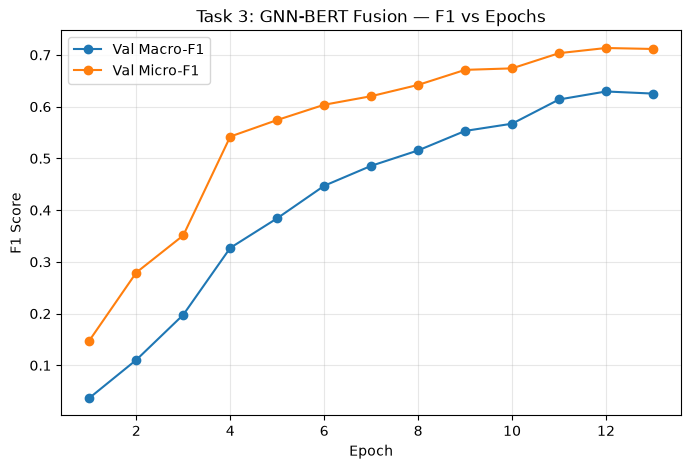

In [13]:
test_loss_fusion, test_macro_f1_fusion, test_micro_f1_fusion = evaluate_fusion(test_loader_fusion)
print(f"FUSION TEST: loss={test_loss_fusion:.4f} | macro_f1={test_macro_f1_fusion:.4f} | micro_f1={test_micro_f1_fusion:.4f}")

torch.save(fusion_model.state_dict(), os.path.join(RESULTS_DIR, "task3_fusion_model.pt"))
with open(os.path.join(RESULTS_DIR, "task3_fusion_history.json"), "w") as f:
    json.dump(fusion_history, f, indent=2)

import matplotlib.pyplot as plt
epochs_range = range(1, len(fusion_history["val_macro_f1"]) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, fusion_history["val_macro_f1"], marker='o', label="Val Macro-F1")
plt.plot(epochs_range, fusion_history["val_micro_f1"], marker='o', label="Val Micro-F1")
plt.xlabel("Epoch"); plt.ylabel("F1 Score")
plt.title("Task 3: GNN-BERT Fusion — F1 vs Epochs")
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(RESULTS_DIR, "plots/task3_f1_curve.png"), dpi=150)
plt.show()

Step 7 — Ablation models: BERT-only, GNN-only, Early-Concat

In [ ]:
class BertOnlyAblation(nn.Module):
    def __init__(self, num_tags=30):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.classifier = nn.Linear(768, num_tags)
    def forward(self, graph_batch, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.classifier(cls)

class GNNOnlyAblation(nn.Module):
    def __init__(self, num_tags=30, hidden=64):
        super().__init__()
        self.conv1 = SAGEConv(12, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.classifier = nn.Linear(hidden, num_tags)
    def forward(self, graph_batch, input_ids, attention_mask):
        x = F.relu(self.conv1(graph_batch.x, graph_batch.edge_index))
        x = F.relu(self.conv2(x, graph_batch.edge_index))
        g = global_mean_pool(x, graph_batch.batch)
        return self.classifier(g)

class EarlyConcatAblation(nn.Module):
    def __init__(self, num_tags=30, gnn_hidden=64, bert_hidden=768):
        super().__init__()
        self.conv1 = SAGEConv(12, gnn_hidden)
        self.conv2 = SAGEConv(gnn_hidden, gnn_hidden)
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.classifier = nn.Linear(gnn_hidden + bert_hidden, num_tags)  
    def forward(self, graph_batch, input_ids, attention_mask):
        x = F.relu(self.conv1(graph_batch.x, graph_batch.edge_index))
        x = F.relu(self.conv2(x, graph_batch.edge_index))
        g = global_mean_pool(x, graph_batch.batch)
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        t = out.last_hidden_state[:, 0, :]  
        z = torch.cat([g, t], dim=-1)
        return self.classifier(z)

Step 8 — Shared training function, with proper best-checkpoint saving

In [ ]:
def train_ablation(model, name, epochs=10, patience=3):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = AdamW(model.parameters(), lr=2e-5)
    history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_micro_f1": []}
    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for graph_batch, input_ids, attn_mask, labels in tqdm(train_loader_fusion, desc=f"{name} Epoch {epoch+1}", leave=False):
            graph_batch = graph_batch.to(device)
            input_ids, attn_mask, labels = input_ids.to(device), attn_mask.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(graph_batch, input_ids, attn_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        all_preds, all_labels, val_loss = [], [], 0
        with torch.no_grad():
            for graph_batch, input_ids, attn_mask, labels in val_loader_fusion:
                graph_batch = graph_batch.to(device)
                input_ids, attn_mask, labels = input_ids.to(device), attn_mask.to(device), labels.to(device)
                logits = model(graph_batch, input_ids, attn_mask)
                val_loss += criterion(logits, labels).item()
                preds = (torch.sigmoid(logits) > 0.5).float()
                all_preds.append(preds.cpu().numpy())
                all_labels.append(labels.cpu().numpy())
        val_loss /= len(val_loader_fusion)
        all_preds, all_labels = np.concatenate(all_preds), np.concatenate(all_labels)
        val_macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
        val_micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)

        history["train_loss"].append(train_loss/len(train_loader_fusion))
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(val_macro_f1)
        history["val_micro_f1"].append(val_micro_f1)
        print(f"{name} Epoch {epoch+1}: train_loss={train_loss/len(train_loader_fusion):.4f} | val_loss={val_loss:.4f} | val_macro_f1={val_macro_f1:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

    model.load_state_dict(best_state)  
    return model, history

Step 9 — Run all three ablations

In [16]:
results_table = {}

bert_only, bert_only_history = train_ablation(BertOnlyAblation(30), "BERT-only")
gnn_only, gnn_only_history = train_ablation(GNNOnlyAblation(30), "GNN-only")
early_concat, early_concat_history = train_ablation(EarlyConcatAblation(30), "Early-Concat")

for name, model in [("BERT-only", bert_only), ("GNN-only", gnn_only), ("Early-Concat", early_concat)]:
    model.eval()
    all_preds, all_labels, test_loss = [], [], 0
    criterion = nn.BCEWithLogitsLoss()
    with torch.no_grad():
        for graph_batch, input_ids, attn_mask, labels in test_loader_fusion:
            graph_batch = graph_batch.to(device)
            input_ids, attn_mask, labels = input_ids.to(device), attn_mask.to(device), labels.to(device)
            logits = model(graph_batch, input_ids, attn_mask)
            test_loss += criterion(logits, labels).item()
            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    all_preds, all_labels = np.concatenate(all_preds), np.concatenate(all_labels)
    results_table[name] = {
        "test_macro_f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "test_micro_f1": f1_score(all_labels, all_preds, average="micro", zero_division=0),
    }

results_table["Cross-Attention (Fusion)"] = {"test_macro_f1": test_macro_f1_fusion, "test_micro_f1": test_micro_f1_fusion}
print(json.dumps(results_table, indent=2))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2919.89it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT-only Epoch 1: train_loss=0.2978 | val_loss=0.2332 | val_macro_f1=0.0607


BERT-only Epoch 2: train_loss=0.2121 | val_loss=0.2025 | val_macro_f1=0.1756


BERT-only Epoch 3: train_loss=0.1820 | val_loss=0.1799 | val_macro_f1=0.2326


BERT-only Epoch 4: train_loss=0.1593 | val_loss=0.1630 | val_macro_f1=0.3844


...

Early-Concat Epoch 6: train_loss=0.1299 | val_loss=0.1421 | val_macro_f1=0.4613


Early-Concat Epoch 7: train_loss=0.1166 | val_loss=0.1418 | val_macro_f1=0.5211


Early-Concat Epoch 8: train_loss=0.1032 | val_loss=0.1312 | val_macro_f1=0.5645


Early-Concat Epoch 9: train_loss=0.0910 | val_loss=0.1285 | val_macro_f1=0.5747


Early-Concat Epoch 10: train_loss=0.0813 | val_loss=0.1241 | val_macro_f1=0.5821
{
  "BERT-only": {
    "test_macro_f1": 0.5522425004824029,
    "test_micro_f1": 0.7158836689038032
  },
  "GNN-only": {
    "test_macro_f1": 0.0,
    "test_micro_f1": 0.0
  },
  "Early-Concat": {
    "test_macro_f1": 0.532984437897768,
    "test_micro_f1": 0.7123287671232876
  },
  "Cross-Attention (Fusion)": {
    "test_macro_f1": 0.5328676757900734,
    "test_micro_f1": 0.7006651884700665
  }
}


In [17]:
gnn_only.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for graph_batch, input_ids, attn_mask, labels in test_loader_fusion:
        graph_batch = graph_batch.to(device)
        logits = gnn_only(graph_batch, input_ids.to(device), attn_mask.to(device))
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
print("Total predicted positives:", all_preds.sum())
print("Total actual positives:", all_labels.sum())
print("Sigmoid output range:", torch.sigmoid(logits).min().item(), "to", torch.sigmoid(logits).max().item())

Total predicted positives: 0.0
Total actual positives: 248.0
Sigmoid output range: 0.11376286298036575 to 0.35659259557724


Step 10 — t-SNE visualization of fused embeddings

Embeddings shape: (116, 832)


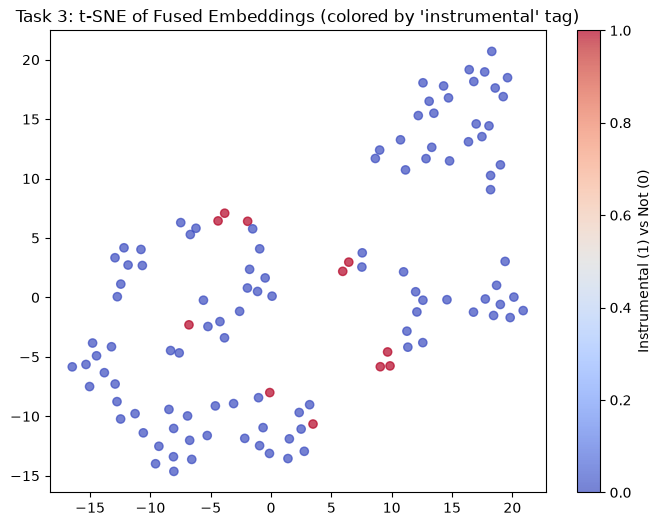

In [18]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def get_fusion_embeddings(model, loader):
    model.eval()
    all_z, all_labels = [], []
    with torch.no_grad():
        for graph_batch, input_ids, attn_mask, labels in loader:
            graph_batch = graph_batch.to(device)
            input_ids, attn_mask = input_ids.to(device), attn_mask.to(device)

            x = F.relu(model.conv1(graph_batch.x, graph_batch.edge_index))
            x = F.relu(model.conv2(x, graph_batch.edge_index))
            g = global_mean_pool(x, graph_batch.batch)

            bert_out = model.bert(input_ids=input_ids, attention_mask=attn_mask)
            H_text = bert_out.last_hidden_state
            Q = model.query_proj(g).unsqueeze(1)
            K = model.key_proj(H_text)
            V = model.value_proj(H_text)
            attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / (K.size(-1) ** 0.5)
            attn_weights = F.softmax(attn_scores, dim=-1)
            attended_text = torch.matmul(attn_weights, V).squeeze(1)

            z = torch.cat([g, attended_text], dim=-1)
            all_z.append(z.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.concatenate(all_z), np.concatenate(all_labels)

z_embeddings, z_labels = get_fusion_embeddings(fusion_model, test_loader_fusion)
print("Embeddings shape:", z_embeddings.shape)

tsne = TSNE(n_components=2, random_state=42, perplexity=15)
z_2d = tsne.fit_transform(z_embeddings)

instrumental_idx = top30_aspects.index("instrumental")
colors = z_labels[:, instrumental_idx]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=colors, cmap="coolwarm", alpha=0.7)
plt.colorbar(scatter, label="Instrumental (1) vs Not (0)")
plt.title("Task 3: t-SNE of Fused Embeddings (colored by 'instrumental' tag)")
plt.savefig(os.path.join(RESULTS_DIR, "plots/task3_tsne.png"), dpi=150)
plt.show()

Step 11 — 3 case studies (final Task 3 deliverable)

In [ ]:
def get_attention_and_prediction(model, graph, input_ids, attn_mask, tokenizer):
    model.eval()
    with torch.no_grad():
        graph_batch = Batch.from_data_list([graph]).to(device)
        input_ids_b = input_ids.unsqueeze(0).to(device)
        attn_mask_b = attn_mask.unsqueeze(0).to(device)

        x = F.relu(model.conv1(graph_batch.x, graph_batch.edge_index))
        x = F.relu(model.conv2(x, graph_batch.edge_index))
        g = global_mean_pool(x, graph_batch.batch)

        bert_out = model.bert(input_ids=input_ids_b, attention_mask=attn_mask_b)
        H_text = bert_out.last_hidden_state
        Q = model.query_proj(g).unsqueeze(1)
        K = model.key_proj(H_text)
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / (K.size(-1) ** 0.5)
        attn_weights = F.softmax(attn_scores, dim=-1).squeeze().cpu().numpy()

        V = model.value_proj(H_text)
        attended_text = torch.matmul(F.softmax(attn_scores, dim=-1), V).squeeze(1)
        z = torch.cat([g, attended_text], dim=-1)
        logits = model.classifier(z)
        preds = (torch.sigmoid(logits) > 0.5).float().cpu().numpy()[0]

    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    real_len = attn_mask.sum().item() 
    return tokens[:real_len], attn_weights[:real_len], preds

# Pick 3 test clips
case_indices = [0, 1, 2]
for idx in case_indices:
    row = mc_test.iloc[idx]
    graph = torch.load(os.path.join(MC_GRAPH_DIR, f"{row['ytid']}.pt"), weights_only=False)
    tokens_full = tokenizer(row["caption"], padding="max_length", truncation=True, max_length=128, return_tensors="pt")

    tokens, weights, preds = get_attention_and_prediction(
        fusion_model, graph, tokens_full["input_ids"].squeeze(0), tokens_full["attention_mask"].squeeze(0), tokenizer
    )

    top5_idx = np.argsort(weights)[-5:][::-1]
    top5_words = [(tokens[i], round(float(weights[i]), 3)) for i in top5_idx]

    true_tags = [top30_aspects[i] for i in range(30) if row[top30_aspects[i]] == 1]
    pred_tags = [top30_aspects[i] for i in range(30) if preds[i] == 1]

    print(f"YTID: {row['ytid']}")
    print(f"Caption: {row['caption']}")
    print(f"Top-5 attended words (word, attention weight): {top5_words}")
    print(f"True tags: {true_tags}")
    print(f"Predicted tags: {pred_tags}")
    print("=" * 80)

YTID: 8UhdwnsckJ8
Caption: The low quality recording features a tutorial that contains a flat male vocal talking over acoustic guitar strummed chords. The recording is noisy and in mono.
Top-5 attended words (word, attention weight): [('.', 0.007), ('[CLS]', 0.007), ('recording', 0.007), ('mono', 0.007), ('noisy', 0.007)]
True tags: ['low quality', 'noisy', 'mono']
Predicted tags: ['low quality', 'noisy', 'mono']
YTID: 50fuQm8B2Yg
Caption: This jazz song features a saxophone playing the main melody. This is accompanied by percussion playing a jazz beat. A piano plays jazz chords. The double bass plays the root notes with flourishes and fills. This song is the outro of a song and abruptly pauses. The mood of this song is happy. There are no voices in this song. This is an instrumental song. This song can be played in a luxury bar.
Top-5 attended words (word, attention weight): [('.', 0.009), ('.', 0.009), ('.', 0.009), ('.', 0.009), ('.', 0.009)]
True tags: ['instrumental', 'piano']
Pre

In [ ]:
def get_attention_masked(model, graph, input_ids, attn_mask, tokenizer):
    model.eval()
    with torch.no_grad():
        graph_batch = Batch.from_data_list([graph]).to(device)
        input_ids_b = input_ids.unsqueeze(0).to(device)
        attn_mask_b = attn_mask.unsqueeze(0).to(device)

        x = F.relu(model.conv1(graph_batch.x, graph_batch.edge_index))
        x = F.relu(model.conv2(x, graph_batch.edge_index))
        g = global_mean_pool(x, graph_batch.batch)

        bert_out = model.bert(input_ids=input_ids_b, attention_mask=attn_mask_b)
        H_text = bert_out.last_hidden_state
        Q = model.query_proj(g).unsqueeze(1)
        K = model.key_proj(H_text)
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / (K.size(-1) ** 0.5)

        
        mask = attn_mask_b.unsqueeze(1) == 0
        attn_scores = attn_scores.masked_fill(mask, float('-inf'))
        attn_weights = F.softmax(attn_scores, dim=-1).squeeze().cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    real_len = attn_mask.sum().item()
    return tokens[:real_len], attn_weights[:real_len]

# Re-check case 1
row = mc_test.iloc[0]
graph = torch.load(os.path.join(MC_GRAPH_DIR, f"{row['ytid']}.pt"), weights_only=False)
tokens_full = tokenizer(row["caption"], padding="max_length", truncation=True, max_length=128, return_tensors="pt")
tokens, weights = get_attention_masked(fusion_model, graph, tokens_full["input_ids"].squeeze(0), tokens_full["attention_mask"].squeeze(0), tokenizer)
top5_idx = np.argsort(weights)[-5:][::-1]
print([(tokens[i], round(float(weights[i]), 3)) for i in top5_idx])

In [ ]:
# Save case studies to results/retrieval_examples 
case_studies_output = []
for idx in case_indices:
    row = mc_test.iloc[idx]
    graph = torch.load(os.path.join(MC_GRAPH_DIR, f"{row['ytid']}.pt"), weights_only=False)
    tokens_full = tokenizer(row["caption"], padding="max_length", truncation=True, max_length=128, return_tensors="pt")
    tokens, weights = get_attention_masked(fusion_model, graph, tokens_full["input_ids"].squeeze(0),
                                            tokens_full["attention_mask"].squeeze(0), tokenizer)
    top5_idx = np.argsort(weights)[-5:][::-1]
    case_studies_output.append({
        "ytid": row["ytid"],
        "caption": row["caption"],
        "top5_attended_words": [(tokens[i], float(weights[i])) for i in top5_idx],
        "true_tags": [top30_aspects[i] for i in range(30) if row[top30_aspects[i]] == 1],
    })

with open(os.path.join(RESULTS_DIR, "task3_case_studies.json"), "w") as f:
    json.dump(case_studies_output, f, indent=2)

with open(os.path.join(RESULTS_DIR, "task3_ablation_results.json"), "w") as f:
    json.dump(results_table, f, indent=2)

print("All Task 3 deliverables saved.")

All Task 3 deliverables saved.
